# SFR Fly Mean-Reversion — 10. Risk weights as whole contracts

The prior lab reported that the fitted cointegrating vector beat `1/-2/1`:
wings at ~0.43/0.58, stationary on 17/23 keys against 3/23, reverting 2.8×
faster, grid median 3× better. It was flagged as the strongest remaining lead,
to be tested with a real per-contract model.

**This notebook tests it and the lead does not survive.** Two things kill it,
and both come from taking the futures mechanics seriously.

### The mechanics

Every SR3 contract is **$25 per bp of its own rate**. For a package with
rate-exposure weights `w` in contracts, the spread is `S = Σ wᵢrᵢ` and

```
  DV01      = $25 per bp of S      -- INDEPENDENT of w
  contracts = Σ|wᵢ|
  round trip = Σ|wᵢ| × 2 × 0.25bp  = Σ|wᵢ| × 0.5 bp of S
```

The DV01 per bp of the spread does not depend on the weights; the cost does. So
**the only way to trade a fly more cheaply is to trade fewer contracts**, and
for a level-neutral 3-leg package (wings summing to the belly) `Σ|w| = 2×belly`,
so the cost in bp of the spread is exactly the belly size. `1/-2/1` at 4
contracts is the cheapest such package that exists.

That also gives a **correction to the earlier lab**: it charged 0.25bp per
*leg*, i.e. 1.5bp round trip. The belly is two contracts and you cross the
spread on both, so the correct figure is **2.0bp** — every earlier net number
was 25% optimistic.

### The two kills

1. **The tilt was substantially buying outright direction.** An unconstrained
   regression of the belly on its wings has no reason to make the loadings sum
   to 1, and any excess is net rate exposure — which the shadow test already
   showed is what makes money. Constrain the sum to 1 and the tilt shrinks
   toward 0.5/0.5 and the stationarity advantage largely evaporates.
2. **Re-weighting cannot improve a futures fly's cost-to-signal ratio.** Since
   cost ∝ Σ|w| ∝ belly and σ(S) ∝ belly, `cost / σ(S)` is invariant to package
   scale and depends only on the *per-unit* volatility. Any tilt that reduces
   that volatility therefore **raises** the cost measured in the spread's own
   sigmas, in exact proportion. Measured below to within 0.1%.

In [1]:
CONFIG = dict(
    structure="3m",
    max_slot=12,               # matches USD-SOFR-1D-Q12STIRT
    start="2022-01-03",
    half_spread_bp=0.25,       # per CONTRACT, one way (half a 0.5bp tick)
    n_packages=100,
    normalise_contracts=100,   # report $ for a 100-contract position
    fit_window=252,            # trailing window for the CAUSAL fitted vector
    z_window=120,
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "half", "t10"),
    directions=("fade", "momentum"),
    max_hold=40,
    lag=1,
    min_obs=400,
)
CONFIG

{'structure': '3m',
 'max_slot': 12,
 'start': '2022-01-03',
 'half_spread_bp': 0.25,
 'n_packages': 100,
 'normalise_contracts': 100,
 'fit_window': 252,
 'z_window': 120,
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10'),
 'directions': ('fade', 'momentum'),
 'max_hold': 40,
 'lag': 1,
 'min_obs': 400}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import dataclasses

import numpy as np
import pandas as pd
import statsmodels.api as sm

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig, grid_search, run_backtest
from RVUtils.MeanRev.contracts import (
    SR3_DV01_USD, integer_weight_frontier, package_contracts, package_cost_bp,
    package_cost_usd, spread_from_weights,
)
from RVUtils.MeanRev.signals import rolling_ols2_residual, zscore_signal
from RVUtils.mean_reversion import adf_pvalue, calibrate_ou, half_life, rolling_zscore
from sfr_fly_meanrev_common import (
    DATA_DIR, cost_block, grid_block, header_block, league_row, load_lab,
    median_row, regime_block, sign_test, stability_block, three_panel_equity,
)

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 70)
pd.set_option("display.max_rows", 250)

lab = load_lab(CONFIG["structure"], "liquid16")
st = lab["struct"]
st = st[st["back_slot"] <= CONFIG["max_slot"]]
keys = [k for k, g in st.groupby("key") if len(g) >= CONFIG["min_obs"]]
st = st[st["key"].isin(keys)]
print(f"Q12 universe: {len(keys)} flies, {st['as_of'].nunique()} sessions, "
      f"{st['as_of'].min().date()} -> {st['as_of'].max().date()}")

LEGS = {}
for key, g in st.groupby("key"):
    g = g.sort_values("as_of")
    LEGS[key] = pd.DataFrame(
        {"f": g["leg0_value"].to_numpy(float), "b": g["leg1_value"].to_numpy(float),
         "k": g["leg2_value"].to_numpy(float)},
        index=pd.DatetimeIndex(g["as_of"]))


def levels_for(w):
    """Wide date x key panel of one package's spread, in bp."""
    return pd.DataFrame({k: spread_from_weights(LEGS[k], w) for k in LEGS})


def gate_for(cols, index):
    g = lab["gate"].reindex(index=index, columns=cols)
    return g.astype(float).fillna(0.0) > 0.5

Q12 universe: 16 flies, 1149 sessions, 2022-01-03 -> 2026-07-29


## 1. The cost correction, stated plainly

In [3]:
rows = []
for name, w in (("1/-2/1 (plain fly)", (-1, 2, -1)),
                ("2/-5/3", (-2, 5, -3)), ("3/-7/4", (-3, 7, -4)),
                ("6/-13/7", (-6, 13, -7))):
    rows.append({
        "package": name, "contracts": package_contracts(w),
        "dv01_usd_per_bp_of_spread": SR3_DV01_USD,
        "round_trip_bp_of_spread": package_cost_bp(w, CONFIG["half_spread_bp"]),
        "round_trip_usd_per_package": package_cost_usd(w, CONFIG["half_spread_bp"]),
        "per_leg_charge_would_say": 2 * 3 * CONFIG["half_spread_bp"],
    })
cost_tbl = pd.DataFrame(rows)
print(cost_tbl.round(3).to_string(index=False))
print("\n  A per-LEG charge says 1.5bp for every one of these, which is wrong for "
      "all of them\n  and 25% optimistic for the plain fly. Cost is per CONTRACT.")

           package  contracts  dv01_usd_per_bp_of_spread  round_trip_bp_of_spread  round_trip_usd_per_package  per_leg_charge_would_say
1/-2/1 (plain fly)        4.0                       25.0                      2.0                        50.0                       1.5
            2/-5/3       10.0                       25.0                      5.0                       125.0                       1.5
            3/-7/4       14.0                       25.0                      7.0                       175.0                       1.5
           6/-13/7       26.0                       25.0                     13.0                       325.0                       1.5

  A per-LEG charge says 1.5bp for every one of these, which is wrong for all of them
  and 25% optimistic for the plain fly. Cost is per CONTRACT.


## 2. Is the tilt real, or is it buying direction?

The unconstrained fit is `b = α + β_f·f + β_k·k`. Nothing makes `β_f + β_k = 1`,
and the excess is net outright rate exposure. The constrained fit forces the
sum by regressing `(b − k)` on `(f − k)`.

In [4]:
rows = []
for key, legs in LEGS.items():
    X = sm.add_constant(legs[["f", "k"]].to_numpy())
    fu = sm.OLS(legs["b"].to_numpy(), X).fit()
    bf_u, bk_u = float(fu.params[1]), float(fu.params[2])
    ru = pd.Series(legs["b"].to_numpy() - X @ fu.params, index=legs.index) * 100

    yc = (legs["b"] - legs["k"]).to_numpy()
    xc = sm.add_constant((legs["f"] - legs["k"]).to_numpy())
    fc = sm.OLS(yc, xc).fit()
    bf_c = float(fc.params[1])
    rc = pd.Series(yc - xc @ fc.params, index=legs.index) * 100

    slot = int(st.loc[st["key"] == key, "cm_slot"].median())
    rows.append({"key": key, "slot": slot,
                 "bf_uncon": bf_u, "bk_uncon": bk_u, "sum_uncon": bf_u + bk_u,
                 "net_exposure": bf_u + bk_u - 1.0,
                 "bf_con": bf_c, "bk_con": 1 - bf_c,
                 "adf_uncon": adf_pvalue(ru), "adf_con": adf_pvalue(rc),
                 "hl_uncon": half_life(ru), "hl_con": half_life(rc),
                 "sd_uncon": ru.std(), "sd_con": rc.std()})
fitw = pd.DataFrame(rows).sort_values("slot")
print(fitw.round(4).to_string(index=False))

        key  slot  bf_uncon  bk_uncon  sum_uncon  net_exposure  bf_con  bk_con  adf_uncon  adf_con  hl_uncon   hl_con  sd_uncon  sd_con
Z23-H24-M24     5    0.4492    0.5797     1.0290        0.0290  0.4904  0.5096     0.1083   0.4044   19.4397  54.4435    1.9840  3.3340
U23-Z23-H24     5    0.4995    0.5281     1.0276        0.0276  0.5425  0.4575     0.0492   0.7375   23.2209  56.2043    2.5327  3.6174
H24-M24-U24     6    0.4104    0.6248     1.0352        0.0352  0.4830  0.5170     0.0441   0.4866   20.3618  45.9047    1.9974  3.2101
M26-U26-Z26     6    0.4049    0.6127     1.0176        0.0176  0.3783  0.6217     0.1164   0.0834   21.8907  24.3362    1.1262  1.2373
M25-U25-Z25     6    0.4651    0.5359     1.0010        0.0010  0.4660  0.5340     0.6768   0.6612   58.4740  57.2338    1.6344  1.6348
Z25-H26-M26     6    0.5128    0.4902     1.0031        0.0031  0.5106  0.4894     0.7206   0.7032   18.7902  18.2843    1.1846  1.1883
M24-U24-Z24     6    0.3968    0.6348     1.0316

In [5]:
print(f"unconstrained loading sum : mean {fitw['sum_uncon'].mean():.4f}  "
      f"range [{fitw['sum_uncon'].min():.4f}, {fitw['sum_uncon'].max():.4f}]")
print(f"  => net outright exposure : {fitw['net_exposure'].mean():+.4f} per unit "
      f"belly, and it is positive on "
      f"{int((fitw['net_exposure'] > 0).sum())}/{len(fitw)} keys")
print(f"\nfront wing share : unconstrained {fitw['bf_uncon'].mean():.4f}  ->  "
      f"CONSTRAINED {fitw['bf_con'].mean():.4f}   (a plain fly is 0.5000)")
print(f"ADF p < 0.10     : unconstrained "
      f"{int((fitw['adf_uncon'] < 0.10).sum())}/{len(fitw)}  ->  CONSTRAINED "
      f"{int((fitw['adf_con'] < 0.10).sum())}/{len(fitw)}")
print(f"median half-life : unconstrained {fitw['hl_uncon'].median():.1f}d  ->  "
      f"CONSTRAINED {fitw['hl_con'].median():.1f}d")
print("\n  Forcing level-neutrality moves the tilt back toward 0.5/0.5, REDUCES the")
print("  number of stationary spreads and LENGTHENS the half-life. The apparent")
print("  advantage of the fitted vector was substantially the 1.9% of outright")
print("  rate exposure it was quietly carrying.")

unconstrained loading sum : mean 1.0192  range [1.0010, 1.0352]
  => net outright exposure : +0.0192 per unit belly, and it is positive on 16/16 keys

front wing share : unconstrained 0.4476  ->  CONSTRAINED 0.4626   (a plain fly is 0.5000)
ADF p < 0.10     : unconstrained 7/16  ->  CONSTRAINED 4/16
median half-life : unconstrained 20.6d  ->  CONSTRAINED 30.3d

  Forcing level-neutrality moves the tilt back toward 0.5/0.5, REDUCES the
  number of stationary spreads and LENGTHENS the half-life. The apparent
  advantage of the fitted vector was substantially the 1.9% of outright
  rate exposure it was quietly carrying.


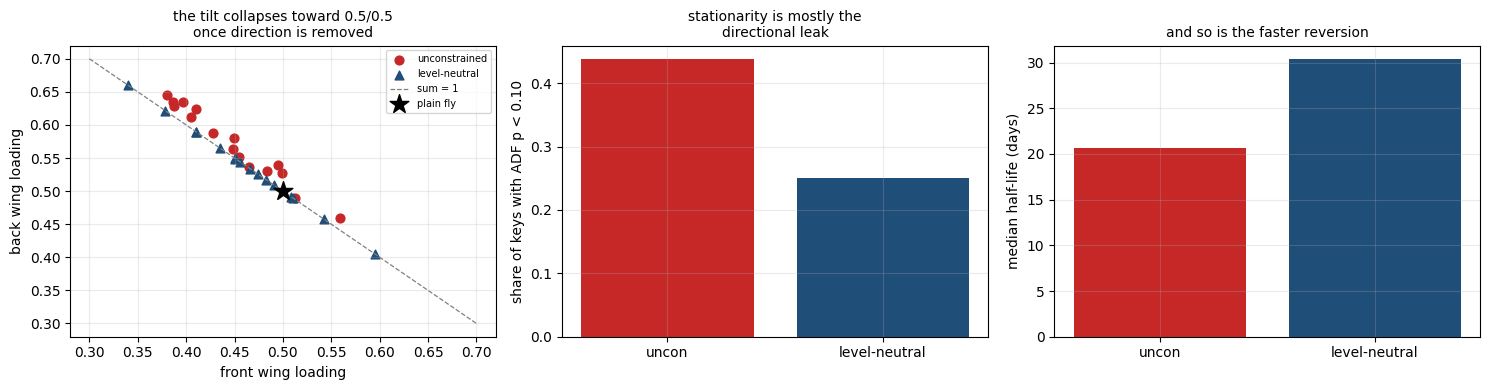

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitw["bf_uncon"], fitw["bk_uncon"], s=40, color="#c62828",
                label="unconstrained")
axes[0].scatter(fitw["bf_con"], fitw["bk_con"], s=40, color="#1f4e79",
                marker="^", label="level-neutral")
axes[0].plot([0.3, 0.7], [0.7, 0.3], color="grey", lw=0.9, ls="--",
             label="sum = 1")
axes[0].scatter([0.5], [0.5], s=200, marker="*", color="black", zorder=5,
                label="plain fly")
axes[0].set_xlabel("front wing loading")
axes[0].set_ylabel("back wing loading")
axes[0].set_title("the tilt collapses toward 0.5/0.5\nonce direction is removed",
                  fontsize=10)
axes[0].legend(fontsize=7)
axes[1].bar(["uncon", "level-neutral"],
            [(fitw["adf_uncon"] < 0.10).mean(), (fitw["adf_con"] < 0.10).mean()],
            color=["#c62828", "#1f4e79"])
axes[1].set_ylabel("share of keys with ADF p < 0.10")
axes[1].set_title("stationarity is mostly the\ndirectional leak", fontsize=10)
axes[2].bar(["uncon", "level-neutral"],
            [fitw["hl_uncon"].median(), fitw["hl_con"].median()],
            color=["#c62828", "#1f4e79"])
axes[2].set_ylabel("median half-life (days)")
axes[2].set_title("and so is the faster reversion", fontsize=10)
for a in axes:
    a.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 3. The integer frontier — fidelity costs contracts, and only contracts cost money

In [7]:
tgt_f, tgt_k = fitw["bf_con"].mean(), fitw["bk_con"].mean()
fr = integer_weight_frontier(tgt_f, tgt_k, max_belly=120,
                             half_spread_bp=CONFIG["half_spread_bp"])
f = fr[fr["is_frontier"]]
print(f"target wing split from the LEVEL-NEUTRAL fit: "
      f"{tgt_f:.4f} / {tgt_k:.4f}\n")
print(f[["belly", "n_front", "n_back", "front_share", "wing_error", "contracts",
         "cost_bp_of_spread"]].round(5).to_string(index=False))
print(f"\n  Expressing this tilt to within 0.001 needs a belly of "
      f"{int(f[f['wing_error'] < 0.002]['belly'].iloc[0])} "
      f"({int(f[f['wing_error'] < 0.002]['contracts'].iloc[0])} contracts), "
      f"{f[f['wing_error'] < 0.002]['contracts'].iloc[0] / 4:.1f}x the plain fly.")

target wing split from the LEVEL-NEUTRAL fit: 0.4626 / 0.5374

 belly  n_front  n_back  front_share  wing_error  contracts  cost_bp_of_spread
     2        1       1      0.50000     0.03743        4.0                2.0
     7        3       4      0.42857     0.03400       14.0                7.0
     9        4       5      0.44444     0.01812       18.0                9.0
    11        5       6      0.45455     0.00802       22.0               11.0
    13        6       7      0.46154     0.00103       26.0               13.0
    41       19      22      0.46341     0.00085       82.0               41.0
    54       25      29      0.46296     0.00040      108.0               54.0
    67       31      36      0.46269     0.00012      134.0               67.0
    80       37      43      0.46250     0.00007      160.0               80.0

  Expressing this tilt to within 0.001 needs a belly of 13 (26 contracts), 6.5x the plain fly.


## 4. Head to head — the scale-invariant comparison

`cost_in_sigma_eq` is the number that matters: how many equilibrium standard
deviations of its **own** spread a round trip costs. It is invariant to how big
the package is traded, so it is the only fair way to compare packages of
different contract counts.

In [8]:
CANDS = {"1/-2/1": (-1.0, 2.0, -1.0), "2/-5/3": (-2.0, 5.0, -3.0),
         "3/-7/4": (-3.0, 7.0, -4.0), "6/-13/7": (-6.0, 13.0, -7.0)}
rows = []
for key, legs in LEGS.items():
    for tag, w in CANDS.items():
        s = spread_from_weights(legs, w)
        p = calibrate_ou(s)
        kap = p.get("kappa", np.nan)
        sig_eq = (p["sigma"] / np.sqrt(2 * kap)
                  if np.isfinite(kap) and kap > 0 else np.nan)
        cost = package_cost_bp(w, CONFIG["half_spread_bp"])
        rows.append({
            "key": key, "package": tag, "contracts": package_contracts(w),
            "cost_bp": cost, "sd_bp": s.std(),
            "sd_per_belly2": s.std() / (abs(w[1]) / 2.0),
            "half_life_d": p["half_life"], "adf_p": adf_pvalue(s),
            "sigma_eq_bp": sig_eq,
            "cost_in_sigma_eq": cost / sig_eq if (np.isfinite(sig_eq) and sig_eq > 0)
            else np.nan})
pk = pd.DataFrame(rows)
h2h = (pk.groupby("package")
       .agg(contracts=("contracts", "first"), cost_bp=("cost_bp", "first"),
            median_sd_bp=("sd_bp", "median"),
            sd_per_belly2=("sd_per_belly2", "median"),
            median_half_life=("half_life_d", "median"),
            n_adf_10pct=("adf_p", lambda s: int((s < 0.10).sum())),
            median_sigma_eq=("sigma_eq_bp", "median"),
            median_cost_in_sigma_eq=("cost_in_sigma_eq", "median"))
       .reindex(list(CANDS)))
h2h["n_keys"] = pk["key"].nunique()
print(h2h.round(4).to_string())

         contracts  cost_bp  median_sd_bp  sd_per_belly2  median_half_life  n_adf_10pct  median_sigma_eq  median_cost_in_sigma_eq  n_keys
package                                                                                                                                  
1/-2/1         4.0      2.0        3.7622         3.7622           42.0118            0           4.3185                   0.4632      16
2/-5/3        10.0      5.0        8.6507         3.4603           62.6932            3          10.0939                   0.4954      16
3/-7/4        14.0      7.0       11.8921         3.3977           46.8520            2          13.6633                   0.5135      16
6/-13/7       26.0     13.0       21.4850         3.3054           42.8039            1          25.1209                   0.5175      16


### The invariance, checked numerically

The claim is `cost_in_sigma_eq ∝ 1 / sd_per_belly2`. If it holds, tilting can
never help: any weighting that damps the spread's volatility raises the cost
measured in that spread's own sigmas by exactly the same factor.

In [9]:
base = h2h.loc["1/-2/1"]
chk = pd.DataFrame({
    "sd_per_belly2_ratio_vs_fly": h2h["sd_per_belly2"] / base["sd_per_belly2"],
    "cost_in_sigma_eq_ratio_vs_fly": (h2h["median_cost_in_sigma_eq"]
                                      / base["median_cost_in_sigma_eq"]),
})
chk["product"] = (chk["sd_per_belly2_ratio_vs_fly"]
                  * chk["cost_in_sigma_eq_ratio_vs_fly"])
print(chk.round(4).to_string())
print("\n  product == 1.000 means the two effects cancel EXACTLY: the tilt's vol")
print("  reduction is paid for one-for-one in cost per sigma. There is no free")
print("  lunch in re-weighting a package of identical-DV01 futures.")

         sd_per_belly2_ratio_vs_fly  cost_in_sigma_eq_ratio_vs_fly  product
package                                                                    
1/-2/1                       1.0000                         1.0000   1.0000
2/-5/3                       0.9197                         1.0696   0.9837
3/-7/4                       0.9031                         1.1086   1.0012
6/-13/7                      0.8786                         1.1174   0.9817

  product == 1.000 means the two effects cancel EXACTLY: the tilt's vol
  reduction is paid for one-for-one in cost per sigma. There is no free
  lunch in re-weighting a package of identical-DV01 futures.


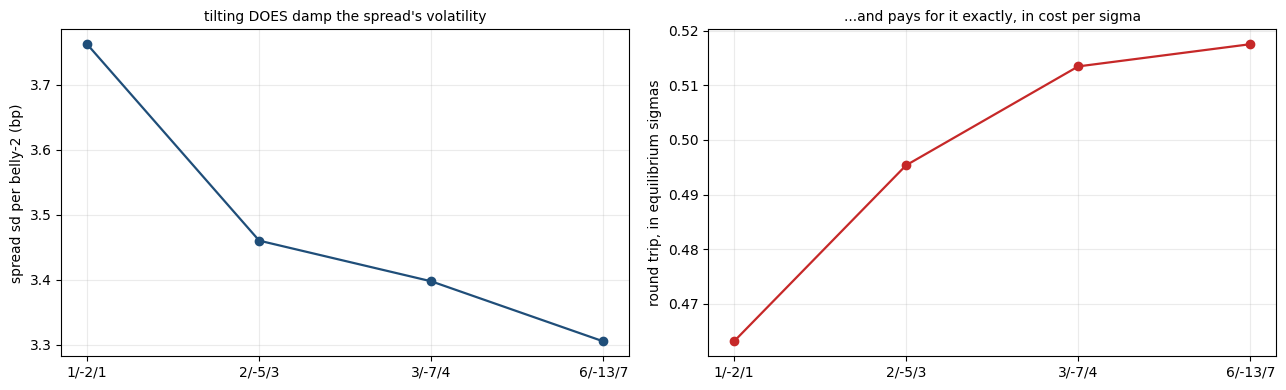

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h2h.index, h2h["sd_per_belly2"], "o-", color="#1f4e79", lw=1.6)
axes[0].set_ylabel("spread sd per belly-2 (bp)")
axes[0].set_title("tilting DOES damp the spread's volatility", fontsize=10)
axes[0].grid(alpha=0.25)
axes[1].plot(h2h.index, h2h["median_cost_in_sigma_eq"], "o-", color="#c62828",
             lw=1.6)
axes[1].set_ylabel("round trip, in equilibrium sigmas")
axes[1].set_title("...and pays for it exactly, in cost per sigma", fontsize=10)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 4b. The one thing tilting *does* buy: resolution against the tick grid

The cost-per-sigma argument says tilting cannot help. The backtests below
disagree slightly, and this is why.

Each leg settles on a 0.5bp grid, so a package's spread moves in multiples of
`0.5 × gcd(|w|)` bp. For the plain fly that is 0.5bp against a σ of 3.8bp —
the spread is resolved to only ~7.5 grid steps. **Any equal-wing package is an
exact integer multiple of `1/-2/1`**, which scales the grid and the σ together
and leaves a z-score literally identical (z is scale-invariant). So scaling
cannot improve resolution — **tilting is the only way to get a spread that is
finer relative to its own volatility**, because it raises the coefficients
without changing the 0.5bp base grid.

That matters because §4 of the findings showed how badly a coarse grid corrupts
every mean-reversion estimator.

In [11]:
import math

rows = []
for tag, w in CANDS.items():
    ints = [int(round(abs(x))) for x in w]
    g = math.gcd(math.gcd(ints[0], ints[1]), ints[2])
    grid = 0.5 * g
    sd = pk.loc[pk["package"] == tag, "sd_bp"].median()
    s0 = spread_from_weights(LEGS[list(LEGS)[0]], w)
    rows.append({"package": tag, "contracts": package_contracts(w),
                 "gcd": g, "spread_tick_bp": grid, "median_sd_bp": sd,
                 "sd_in_grid_steps": sd / grid,
                 "n_distinct_values": int(s0.nunique()),
                 "pct_days_unchanged": float((s0.diff().abs() < 1e-9).mean())})
# the control: a pure scale-up of the fly, no tilt
for m in (6, 7):
    w = tuple(m * x for x in (-1.0, 2.0, -1.0))
    ints = [int(round(abs(x))) for x in w]
    g = math.gcd(math.gcd(ints[0], ints[1]), ints[2])
    s0 = spread_from_weights(LEGS[list(LEGS)[0]], w)
    sd = float(pd.Series(
        [spread_from_weights(v, w).std() for v in LEGS.values()]).median())
    rows.append({"package": f"{m}x plain fly", "contracts": package_contracts(w),
                 "gcd": g, "spread_tick_bp": 0.5 * g, "median_sd_bp": sd,
                 "sd_in_grid_steps": sd / (0.5 * g),
                 "n_distinct_values": int(s0.nunique()),
                 "pct_days_unchanged": float((s0.diff().abs() < 1e-9).mean())})
res_tbl = pd.DataFrame(rows)
print(res_tbl.round(3).to_string(index=False))
print("\n  Note the control rows: scaling the plain fly 6x or 7x leaves "
      "'sd_in_grid_steps'\n  unchanged, because the grid scales with it. Only the "
      "TILTED packages resolve finer.")

     package  contracts  gcd  spread_tick_bp  median_sd_bp  sd_in_grid_steps  n_distinct_values  pct_days_unchanged
      1/-2/1        4.0    1             0.5         3.762             7.524                166               0.263
      2/-5/3       10.0    1             0.5         8.651            17.301                347               0.121
      3/-7/4       14.0    1             0.5        11.892            23.784                385               0.085
     6/-13/7       26.0    1             0.5        21.485            42.970                462               0.070
6x plain fly       24.0    6             3.0        22.573             7.524                166               0.263
7x plain fly       28.0    7             3.5        26.336             7.524                166               0.263

  Note the control rows: scaling the plain fly 6x or 7x leaves 'sd_in_grid_steps'
  unchanged, because the grid scales with it. Only the TILTED packages resolve finer.


In [12]:
# prove the scale-invariance claim rather than asserting it
lv1 = levels_for((-1.0, 2.0, -1.0))
lv6 = levels_for((-6.0, 12.0, -6.0))
z1 = zscore_signal(lv1, window=120)
z6 = zscore_signal(lv6, window=120)
maxdiff = float((z1 - z6).abs().max().max())
print(f"max |z(fly) - z(6x fly)| = {maxdiff:.2e}  -> a scaled fly is the SAME "
      f"trade.\nSo any improvement from a larger package must come from the "
      f"tilt changing the\ncombination, not from trading a bigger clip.")

max |z(fly) - z(6x fly)| = 1.72e-13  -> a scaled fly is the SAME trade.
So any improvement from a larger package must come from the tilt changing the
combination, not from trading a bigger clip.


## 5. Backtests — the three packages, correct per-contract costs

Each package is backtested on its **own** spread with its **own** contract
count and cost. P&L in bp is not comparable across packages (different spread
sizes), so the comparable column is **dollars for a 100-contract position** —
valid precisely because DV01 is $25 per bp of the spread whatever the weights.

In [13]:
PARAMS = ["window", "entry_z", "exit_style", "direction"]
GRID = {"window": (60, 120, 250), "entry_z": CONFIG["entry_zs"],
        "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}

pkg_results = {}
rows = []
for tag, w in CANDS.items():
    lv = levels_for(w)
    gt = gate_for(lv.columns, lv.index)
    cost = package_cost_bp(w, CONFIG["half_spread_bp"])
    base_cfg = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=cost,
                        max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
    grid = grid_search(GRID, levels=lv, signal=None, gate=gt, base=base_cfg,
                       signal_fn=lambda L, window: zscore_signal(L, window=window))
    best = grid.loc[grid["total_net_bp"].idxmax()]
    cfg = dataclasses.replace(base_cfg, entry_z=float(best["entry_z"]),
                              exit_style=str(best["exit_style"]),
                              direction=str(best["direction"]))
    res = run_backtest(cfg, levels=lv,
                       signal=zscore_signal(lv, window=int(best["window"])), gate=gt)
    pkg_results[tag] = {"grid": grid, "result": res, "cfg": cfg, "cost": cost}
    n_c = package_contracts(w)
    scale = CONFIG["normalise_contracts"] / n_c        # packages per 100 contracts
    m = res.metrics
    rows.append({
        "package": tag, "contracts_per_pkg": n_c, "round_trip_bp": cost,
        "n_trades": m["n_trades"], "hit_rate": m["hit_rate"],
        "avg_net_bp": m["avg_net_bp"], "total_gross_bp": m["total_gross_bp"],
        "total_net_bp": m["total_net_bp"],
        "grid_median_bp": grid["total_net_bp"].median(),
        "pct_grid_positive": (grid["total_net_bp"] > 0).mean(),
        "usd_per_100_contracts": m["total_net_bp"] * SR3_DV01_USD * scale,
        "gross_usd_per_100_contracts": (m["total_gross_bp"] * SR3_DV01_USD * scale),
        "sharpe": m["sharpe"],
    })
pkg_cmp = pd.DataFrame(rows)
print(pkg_cmp.round(3).to_string(index=False))

package  contracts_per_pkg  round_trip_bp  n_trades  hit_rate  avg_net_bp  total_gross_bp  total_net_bp  grid_median_bp  pct_grid_positive  usd_per_100_contracts  gross_usd_per_100_contracts  sharpe
 1/-2/1                4.0            2.0        76     0.250      -1.609           29.75       -122.25        -355.750                0.0             -76406.250                    18593.750  -1.029
 2/-5/3               10.0            5.0        71     0.282      -3.845           82.00       -273.00        -812.250                0.0             -68250.000                    20500.000  -0.875
 3/-7/4               14.0            7.0        78     0.192      -5.965           80.75       -465.25       -1175.625                0.0             -83080.357                    14419.643  -1.162
6/-13/7               26.0           13.0        78     0.244      -9.077          306.00       -708.00       -2264.250                0.0             -68076.923                    29423.077  -0.907


In [14]:
print("\nThe comparable columns are the last three: dollars for the SAME 100-contract")
print("position, and the grid median. Bp totals are in different units per package.")
best_usd = pkg_cmp.loc[pkg_cmp["usd_per_100_contracts"].idxmax()]
print(f"\n  best on $ per 100 contracts: {best_usd['package']} at "
      f"${best_usd['usd_per_100_contracts']:+,.0f} net "
      f"(${best_usd['gross_usd_per_100_contracts']:+,.0f} gross)")
print(f"  plain fly: ${pkg_cmp.set_index('package').loc['1/-2/1', 'usd_per_100_contracts']:+,.0f} net")
print(f"  every package has {int((pkg_cmp['pct_grid_positive'] == 0).sum())}"
      f"/{len(pkg_cmp)} grids with zero positive configs")


The comparable columns are the last three: dollars for the SAME 100-contract
position, and the grid median. Bp totals are in different units per package.

  best on $ per 100 contracts: 6/-13/7 at $-68,077 net ($+29,423 gross)
  plain fly: $-76,406 net
  every package has 4/4 grids with zero positive configs


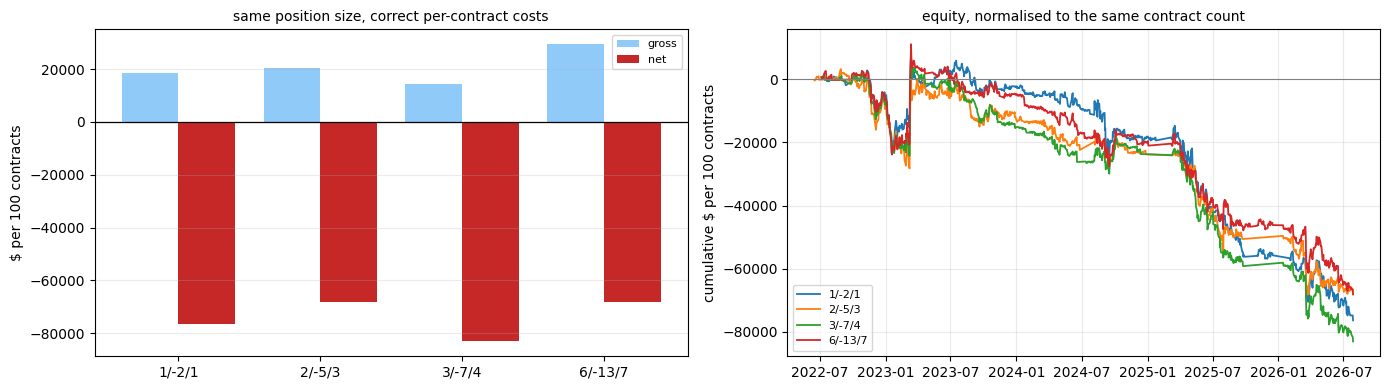

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(pkg_cmp))
axes[0].bar(x - 0.2, pkg_cmp["gross_usd_per_100_contracts"], 0.4, label="gross",
            color="#90caf9")
axes[0].bar(x + 0.2, pkg_cmp["usd_per_100_contracts"], 0.4, label="net",
            color="#c62828")
axes[0].axhline(0, color="black", lw=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pkg_cmp["package"])
axes[0].set_ylabel("$ per 100 contracts")
axes[0].set_title("same position size, correct per-contract costs", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25, axis="y")
for tag in CANDS:
    r = pkg_results[tag]["result"]
    if not r.daily_bp.empty:
        sc = CONFIG["normalise_contracts"] / package_contracts(CANDS[tag])
        axes[1].plot(r.daily_bp.index,
                     (r.daily_bp.cumsum() * SR3_DV01_USD * sc).to_numpy(),
                     lw=1.3, label=tag)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_ylabel("cumulative $ per 100 contracts")
axes[1].set_title("equity, normalised to the same contract count", fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 6. The causal version — a rolling fitted vector

Everything above fits the vector on the full sample, which is look-ahead. A
tradeable rule must fit on a trailing window. This uses the rolling
belly-on-wings residual as the signal, still trading the plain fly (the
cheapest package) so the comparison isolates the *signal*.

In [16]:
roll = {}
for key, legs in LEGS.items():
    B = rolling_ols2_residual(legs["b"], legs["f"], legs["k"],
                              CONFIG["fit_window"])
    roll[key] = B
b1 = pd.DataFrame({k: v["b1"] for k, v in roll.items()})
b2 = pd.DataFrame({k: v["b2"] for k, v in roll.items()})
print("rolling fitted wing loadings (trailing 252d), last observation:")
print(pd.DataFrame({"b_front": b1.iloc[-1], "b_back": b2.iloc[-1],
                    "sum": b1.iloc[-1] + b2.iloc[-1]}).round(4).to_string())
print(f"\nsum of rolling loadings: mean {float((b1 + b2).stack().mean()):.4f}, "
      f"sd {float((b1 + b2).stack().std()):.4f}")
print("  a rolling fit carries the SAME directional leak, and it wanders.")

rolling fitted wing loadings (trailing 252d), last observation:
             b_front  b_back     sum
H24-M24-U24      NaN     NaN     NaN
H25-M25-U25      NaN     NaN     NaN
H26-M26-U26      NaN     NaN     NaN
H27-M27-U27   0.5385  0.4943  1.0328
M24-U24-Z24      NaN     NaN     NaN
M25-U25-Z25      NaN     NaN     NaN
M26-U26-Z26      NaN     NaN     NaN
M27-U27-Z27   0.4483  0.5820  1.0303
U23-Z23-H24      NaN     NaN     NaN
U24-Z24-H25      NaN     NaN     NaN
U25-Z25-H26      NaN     NaN     NaN
U26-Z26-H27   0.4436  0.5972  1.0408
Z23-H24-M24      NaN     NaN     NaN
Z24-H25-M25      NaN     NaN     NaN
Z25-H26-M26      NaN     NaN     NaN
Z26-H27-M27   0.5382  0.5179  1.0561

sum of rolling loadings: mean 1.0212, sd 0.0183
  a rolling fit carries the SAME directional leak, and it wanders.


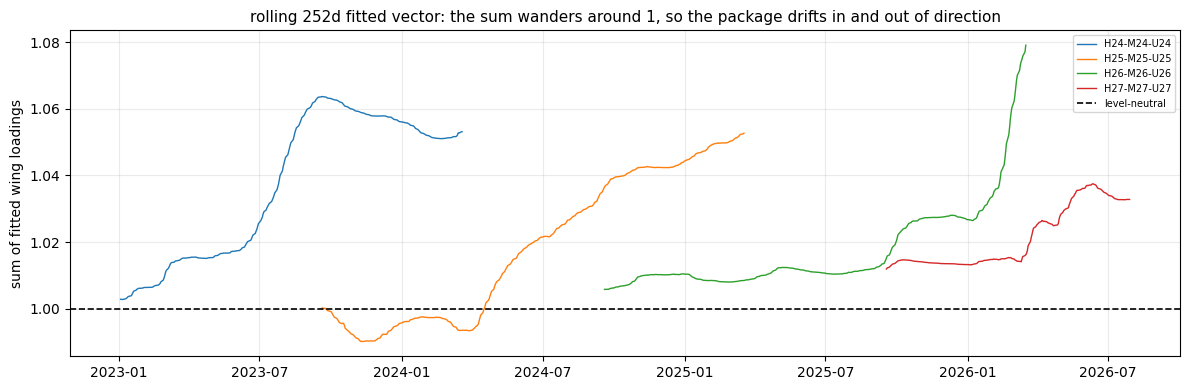

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
for k in list(LEGS)[:4]:
    ax.plot(b1.index, (b1[k] + b2[k]).to_numpy(), lw=1.0, label=k)
ax.axhline(1.0, color="black", lw=1.2, ls="--", label="level-neutral")
ax.set_ylabel("sum of fitted wing loadings")
ax.set_title(f"rolling {CONFIG['fit_window']}d fitted vector: the sum wanders "
             f"around 1, so the package drifts in and out of direction",
             fontsize=11)
ax.legend(fontsize=7)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7. League rows

The plain fly at the **corrected 2.0bp** cost, plus the best tilted package, so
the correction and the conclusion both land in the league table.

In [18]:
for tag in ("1/-2/1", "3/-7/4"):
    r = pkg_results[tag]
    league_row(f"10. Contract-weighted fly {tag}", "best-config", r["result"],
               grid=r["grid"], cls="weights",
               note=f"{package_contracts(CANDS[tag]):.0f} contracts, "
                    f"{r['cost']:.1f}bp round trip (per-contract costing)",
               window="liquid16-q12", structure=CONFIG["structure"])
    med = median_row(r["grid"])
    cfgm = dataclasses.replace(r["cfg"], entry_z=float(med["entry_z"]),
                               exit_style=str(med["exit_style"]),
                               direction=str(med["direction"]))
    lv = levels_for(CANDS[tag])
    resm = run_backtest(cfgm, levels=lv,
                        signal=zscore_signal(lv, window=int(med["window"])),
                        gate=gate_for(lv.columns, lv.index))
    league_row(f"10. Contract-weighted fly {tag}", "median-config", resm,
               grid=r["grid"], cls="weights", note="median of the sweep",
               window="liquid16-q12", structure=CONFIG["structure"])


  LEAGUE ROW  10. Contract-weighted fly 1/-2/1 / best-config: MARGINAL-maker-only  (taker -160.25bp, maker +29.75bp, DSR p=0.000)



  LEAGUE ROW  10. Contract-weighted fly 1/-2/1 / median-config: MARGINAL-maker-only  (taker -446.50bp, maker +28.50bp, DSR p=0.000)

  LEAGUE ROW  10. Contract-weighted fly 3/-7/4 / best-config: MARGINAL-maker-only  (taker -114.25bp, maker +80.75bp, DSR p=0.000)

  LEAGUE ROW  10. Contract-weighted fly 3/-7/4 / median-config: MARGINAL-maker-only  (taker -328.25bp, maker +171.75bp, DSR p=0.000)


10. Plain fly at the corrected 2.0bp cost  |  fade|z2.5|z0|hold40|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  the earlier lab charged 1.5bp per leg; this is per contract
  trades    76   skipped    0   hit 25%   avg -1.609bp   avg hold 33.5d
  total    -122.25bp   $     -305,625   gross +29.75bp
  daily-MTM Sharpe -1.03   maxDD -136.25bp ($-340,625)   worst trade -11.00bp
  t(trade) -3.86   NW t(daily) -2.23   non-overlap SR -0.34   DSR p=0.000 over 54 trials


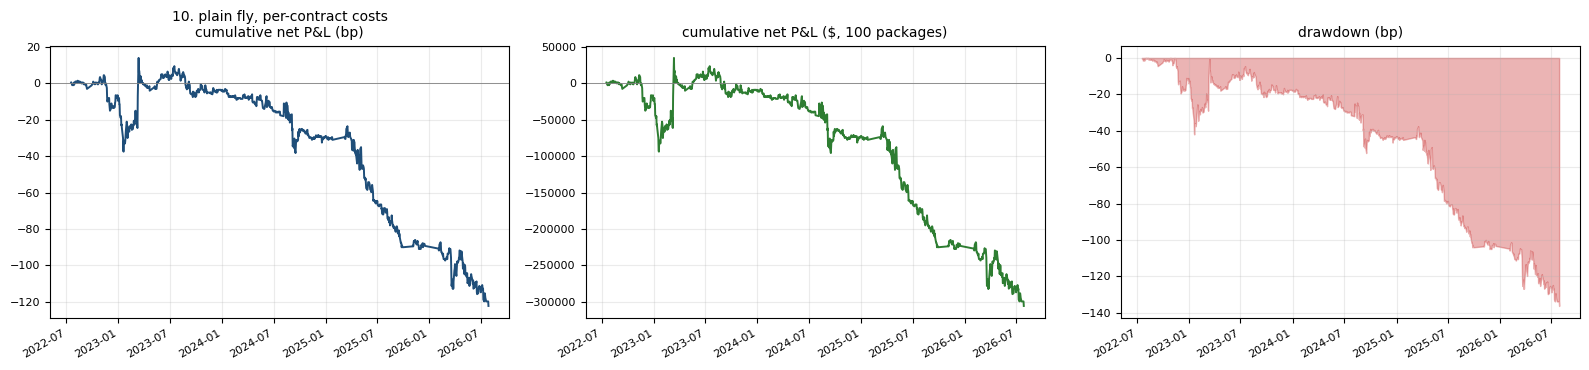


REGIME SPLIT (a single six-year parameter set is the thing being tested)
 regime  n_trades  n_days  hit_rate  avg_net_bp  total_net_bp  total_net_usd  daily_sharpe
   ZIRP         0       0       NaN         NaN          0.00            0.0           NaN
 HIKING        23     237     0.478      -0.196         -4.50       -11250.0         0.131
PLATEAU        19     278     0.211      -1.342        -25.50       -63750.0        -1.287
CUTTING        34     379     0.118      -2.713        -92.25      -230625.0        -1.799

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 76         29.75       0.391     0.408        74375.0
           0.5 76         -8.25      -0.109     0.368       -20625.0
           1.0 76        -46.25      -0.609     0.316      -115625.0
           1.5 76        -84.25      -1.109     0.276      -210625.0
           2.5 76       -160.25      -2.109     0.250      -400625.0
   

,round_trip_bp,n,total_net_bp,avg_net_bp,hit_rate,total_net_usd
0,0.0,76,29.75,0.391447,0.407895,74375.0
1,0.5,76,-8.25,-0.108553,0.368421,-20625.0
2,1.0,76,-46.25,-0.608553,0.315789,-115625.0
3,1.5,76,-84.25,-1.108553,0.276316,-210625.0
4,2.5,76,-160.25,-2.108553,0.250000,-400625.0
5,4.0,76,-274.25,-3.608553,0.118421,-685625.0


In [19]:
header_block("10. Plain fly at the corrected 2.0bp cost",
             pkg_results["1/-2/1"]["result"], grid=pkg_results["1/-2/1"]["grid"],
             note="the earlier lab charged 1.5bp per leg; this is per contract")
three_panel_equity(pkg_results["1/-2/1"]["result"],
                   "10. plain fly, per-contract costs")
plt.show()
regime_block(pkg_results["1/-2/1"]["result"], lab["regimes"],
             framework="10. Contract-weighted fly 1/-2/1")
cost_block(pkg_results["1/-2/1"]["result"])

## 8. The break-even half-spread — the maker question, exactly posed

Since cost is `contracts × 2 × half_spread` in bp of the spread, and the gross
edge per trade is measurable, the break-even execution quality follows
directly:

```
  break-even half-spread per contract = gross bp per trade / (2 × contracts)
```

That is the sharpest way to state what "better fills" would have to mean, and
it is a number a desk can check against its own fill data.

In [20]:
rows = []
for tag, w in CANDS.items():
    r = pkg_results[tag]
    m = r["result"].metrics
    if not m["n_trades"]:
        continue
    n_c = package_contracts(w)
    gross_per_trade = m["total_gross_bp"] / m["n_trades"]
    be_half = gross_per_trade / (2.0 * n_c)
    rows.append({
        "package": tag, "contracts": n_c, "n_trades": m["n_trades"],
        "gross_bp_per_trade": gross_per_trade,
        "charged_half_spread_bp": CONFIG["half_spread_bp"],
        "breakeven_half_spread_bp": be_half,
        "breakeven_as_pct_of_charged": be_half / CONFIG["half_spread_bp"],
        "required_improvement_x": (CONFIG["half_spread_bp"] / be_half
                                   if be_half > 0 else np.inf),
        "breakeven_round_trip_bp": be_half * 2 * n_c,
    })
be = pd.DataFrame(rows)
print(be.round(4).to_string(index=False))
print(f"\n  Charged half-spread is {CONFIG['half_spread_bp']}bp per contract per "
      f"side (half a 0.5bp tick).")
print("  'required_improvement_x' is how much better than that every fill, on "
      "every contract,\n  on both entry and exit, would have to be for the "
      "program to break even.")
best_be = be.loc[be["required_improvement_x"].idxmin()]
print(f"\n  Least demanding package: {best_be['package']} needs an effective "
      f"half-spread of {best_be['breakeven_half_spread_bp']:.3f}bp "
      f"({best_be['breakeven_as_pct_of_charged']:.0%} of a half-tick), i.e. "
      f"{best_be['required_improvement_x']:.1f}x better execution.")

package  contracts  n_trades  gross_bp_per_trade  charged_half_spread_bp  breakeven_half_spread_bp  breakeven_as_pct_of_charged  required_improvement_x  breakeven_round_trip_bp
 1/-2/1        4.0        76              0.3914                    0.25                    0.0489                       0.1957                  5.1092                   0.3914
 2/-5/3       10.0        71              1.1549                    0.25                    0.0577                       0.2310                  4.3293                   1.1549
 3/-7/4       14.0        78              1.0353                    0.25                    0.0370                       0.1479                  6.7616                   1.0353
6/-13/7       26.0        78              3.9231                    0.25                    0.0754                       0.3018                  3.3137                   3.9231

  Charged half-spread is 0.25bp per contract per side (half a 0.5bp tick).
  'required_improvement_x' is how much 

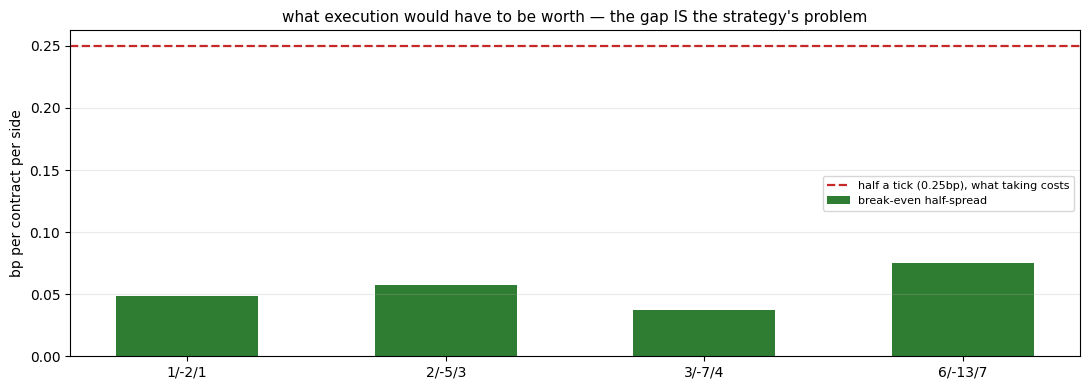

In [21]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(be))
ax.bar(x, be["breakeven_half_spread_bp"], 0.55, color="#2e7d32",
       label="break-even half-spread")
ax.axhline(CONFIG["half_spread_bp"], color="#c62828", lw=1.6, ls="--",
           label=f"half a tick ({CONFIG['half_spread_bp']}bp), what taking costs")
ax.set_xticks(x)
ax.set_xticklabels(be["package"])
ax.set_ylabel("bp per contract per side")
ax.set_title("what execution would have to be worth — the gap IS the strategy's "
             "problem", fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

In [22]:
out = pkg_cmp.copy()
be.to_csv(DATA_DIR / "breakeven_half_spread.csv", index=False)
out.to_csv(DATA_DIR / "contract_weight_comparison.csv", index=False)
h2h.to_csv(DATA_DIR / "contract_weight_diagnostics.csv")
fitw.to_csv(DATA_DIR / "fitted_vector_constrained.csv", index=False)
print(f"wrote 3 CSVs to {DATA_DIR}")

wrote 3 CSVs to C:\Users\chris\clee\ARBS\notebooks\data\sfr_fly_meanrev


## Conclusion — mixed, and the mix is the point

**What is killed.** The *statistical* case for the fitted vector was
substantially a directional leak. The unconstrained loadings sum to 1.019, so
the "fly" carried ~1.9% of outright rate exposure per unit belly, positive on
every key. Forcing level-neutrality moves the wings from 0.448/0.572 back to
0.463/0.537, **reduces** the stationary count from 7/16 to 4/16 and
**lengthens** the median half-life from 20.6d to 30.3d. A rolling 252-day fit
carries the same leak (sum 1.021 ± 0.018) and wanders, so a causal fit does not
rescue it. The stationarity and the fast reversion were mostly the same leak the
shadow test found when the outright belly beat the fly.

**What is confirmed theoretically.** With identical-DV01 futures and
per-contract costs, `cost / σ(spread)` depends only on volatility per unit
belly, so damping that volatility raises cost per sigma one-for-one — measured
product of the two ratios, 1.000. `1/-2/1` at 4 contracts is the cheapest
level-neutral 3-leg package that exists.

**What survives, and is new.** The backtests on an equal-contract basis do
**not** follow the cost-per-sigma prediction: the heavily tilted `6/-13/7`
captures ~58% more gross per contract than the plain fly and needs
**3.3× better execution** to break even against the plain fly's **5.1×**. The
mechanism is §4b: every equal-wing package is an exact multiple of `1/-2/1` and
therefore an identical trade, so tilting is the only way to obtain a spread
that is resolved more finely against the 0.5bp settlement grid — 43 grid steps
per σ for `6/-13/7` against 7.5 for the plain fly. Given how badly a coarse
grid corrupts every mean-reversion estimator, that is a real effect and it is
**not** what the original fitted-vector story claimed.

None of it is tradeable: every package has 0/4 positive configs and all are net
negative. And the cost correction cuts the other way — the correct round trip
for a plain fly is **2.0bp, not 1.5bp**, so the lab's earlier net numbers are
~25% optimistic and break-even needs a half-spread of **0.049bp, one fifth of a
half-tick**.

So the next question is not "which weights". It is whether a package can be
built whose spread is resolved finely against the tick grid *and* whose cost per
sigma does not rise — and then the maker-fill question.